In [1]:
import os, sys, time, warnings, logging
from datetime import date

sys.path.extend([os.path.abspath("DeepHedging"), os.path.abspath("metrics")])
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.mathtext").setLevel(logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, tensorflow as tf
import yfinance as yf, yaml
from tqdm.notebook import tqdm

from DataGenerator import DataGenerator
from DeepHedging import DeepHedging
from utils.data_stationarity import check_stationarity
from utils.data_generation import *
from metrics.eval_functions import *
from metrics.get_params import *
from metrics.fbm_stock_metrics.src.evaluations.summary import full_evaluation_latest
from models.sbts_uni import *            
from models.sbts_uni_markovian import *
from models.sbts_multi_markovian import *
from models.cv_sbts import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

I0000 00:00:1785245309.644467   33789 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785245310.689172   33789 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785245310.689483   33789 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Device: cpu


# Data

In [2]:
N = 60  # window length 

df = yf.download("NVDA", start="2010-01-01", end="2026-01-01", progress=False)
prices = df["Close"].values.flatten()
dates = df.index

train_frac, val_frac = 0.70, 0.15
n_total = len(prices)
n_train = int(n_total * train_frac)
n_val   = int(n_total * val_frac)

prices_train = prices[:n_train]
dates_train  = dates[:n_train]

prices_val   = prices[n_train : n_train + n_val]
prices_test  = prices[n_train + n_val :]

def make_windows(prices, N):
    return np.array([
        prices[i:i+N+1]
        for i in range(len(prices) - N)
    ])

X_train = make_windows(prices_train, N)
X_val   = make_windows(prices_val, N)
print(X_train.shape)

M = X_train.shape[0]

(2756, 61)


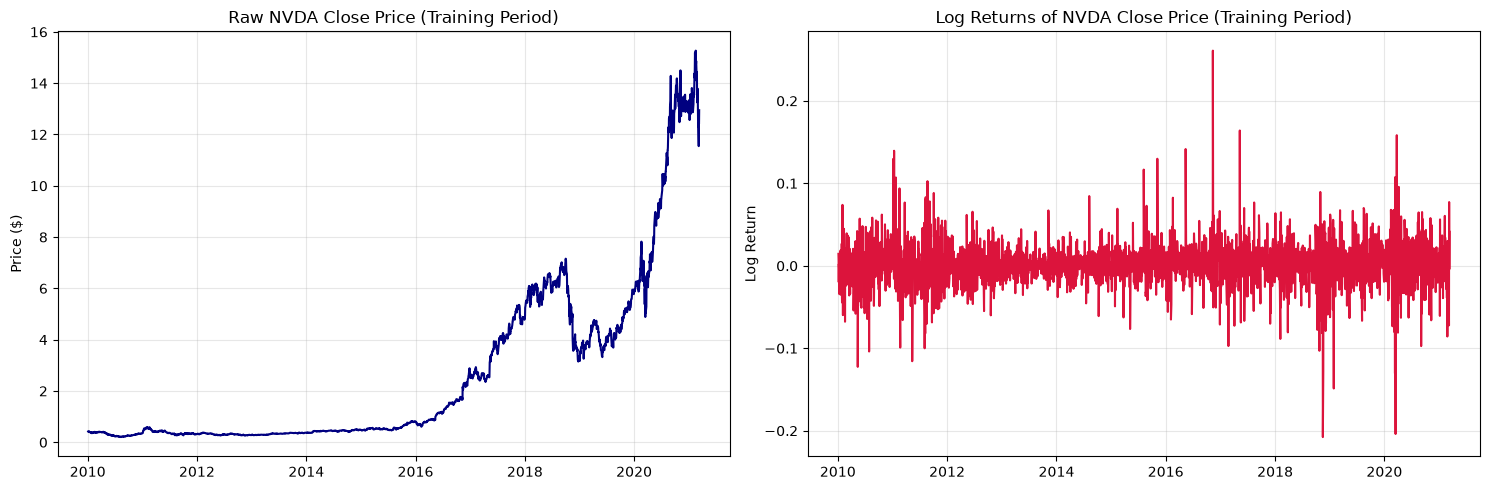

In [3]:
dates_train = df.index[:n_train]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(dates_train, prices_train, color="navy", label="NVDA Close")
axes[0].set_title("Raw NVDA Close Price (Training Period)")
axes[0].set_ylabel("Price ($)")
axes[0].grid(True, alpha=0.3)

log_returns = np.diff(np.log(prices_train))
axes[1].plot(dates_train[1:], log_returns, color="crimson", label="Log Returns")
axes[1].set_title("Log Returns of NVDA Close Price (Training Period)")
axes[1].set_ylabel("Log Return")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
check_stationarity(prices_train, name="Raw NVDA Prices")
check_stationarity(log_returns, name="Daily Log Returns")


--- Stationarity Analysis for: Raw NVDA Prices ---
ADF Statistic: 1.6225
ADF p-value:   9.9792e-01
  => ADF Result: Non-Stationary / Unit Root (Fail to reject H0)
KPSS Statistic: 6.1356
KPSS p-value:   1.0000e-02
  => KPSS Result: Non-Stationary (Reject H0 at 5% significance)

--- Stationarity Analysis for: Daily Log Returns ---
ADF Statistic: -16.5120
ADF p-value:   2.1020e-29
  => ADF Result: Stationary (Reject H0 at 5% significance)
KPSS Statistic: 0.3957
KPSS p-value:   7.9011e-02
  => KPSS Result: Stationary (Fail to reject H0)


/home/minh-hoang/Documents/Research CMAP/Math-fin/Huyen PHAM/SBTS/SBTS/utils/data_stationarity.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(series, regression="c", nlags="auto")


# SBTS synthetic samples generation

- Raw prices: $S_0, S_1,\ldots, S_N$ (observed at $0 = t_0 < t_1 <\ldots < t_N$)

- Log-returns: $R_{t_i} = \log \frac{R_{t_{i}} } {R_{t_{i-1}}} $

- Observed series: $X_{t_i} = \log \frac{S_{t_i}} {S_{t_0}} = \sum_{j=1}^i R_{t_j} $, with $X_{t_0} = 0$.

- Increments: $X_{t_{i+1}} - X_{t_i} = R_{t_{i+1}} $

- Under $\mathbb{W}^\sigma$, the theoretical variance of the increment is:

$ \text{ Var }   (  X_{t_{i+1}} - X_{t_i} $ ) = $ \sigma^2 (t_{i+1} - t_i) =\sigma^2 \Delta t $ (when it is an uniform grid  $  t_{i+1} - t_i = \Delta t $ )

- The empirical variance of the increment is:

$ \text{ Var }   (  X_{t_{i+1}} - X_{t_i}  )= \text{ Var }  (R_{t_{i+1}}) = [\sigma(R)]^2  $ (where $\sigma(R)$ is the empirical std of the log return series) 

- Equating the two variance yieds: $\hat{\sigma} = \frac{\sigma(R)}{\sqrt{\Delta t}}$ with $\hat{\sigma}$ is the estimator for $\sigma$.

- Define the rescaled observed series $\tilde{X_{t_i} } = X_{t_i} /\hat{\sigma}$ and rescaled log-returns $\tilde{R}_{t_i} = R_{t_i} /\hat{\sigma}$

- We have the increments of the rescaled process are:

$ \text{ Var }   (  \tilde{X}_{t_{i+1}} - \tilde{ X}_{t_i} )= \text{ Var }  (\tilde{ R}_{t_{i+1}} ) =  \text{ Var } (R_{t_{i+1}} \cdot \frac{\sqrt{\Delta t}}{\sigma(R)}  )   = \Delta t      $

This is exactly the increment law of the standard 
$\mathbb{W}$ reference (with $σ=1$). So dividing by the true $σ$ turns 
$X$'s reference from $\mathbb{W}^\sigma$ into exactly $\mathbb{W}$.

In [5]:
R = np.log(X_train[:, 1:] / X_train[:, :-1])      

sigma_R = np.std(R)

deltat = 1.0 / N

R_tilde = R * np.sqrt(deltat) / sigma_R 

In [6]:
X_ref = np.concatenate([np.zeros((M, 1)), R_tilde], axis=1)

print("X_ref shape:", X_ref.shape)

# Convert VAL windows using TRAINING sigma_R (no leakage)
R_val = np.log(X_val[:, 1:] / X_val[:, :-1])
R_val_tilde = R_val * np.sqrt(deltat) / sigma_R
X_val_ref = np.concatenate([np.zeros((X_val.shape[0], 1)), R_val_tilde], axis=1)

X_ref shape: (2756, 61)


## CV

In [7]:
from models.cv_sbts import cv_mse_plain, cv_mse_markov

X_train_ref = X_ref

N_pi = 100
deltati = 1.0 / 60
L = 30   # realizations per query path, to estimate the conditional mean
Q = 80   # number of held-out validation query paths

rng = np.random.default_rng(42)
idx_q = rng.choice(X_val_ref.shape[0], size=Q, replace=False)  

# Plain version: grid over h 
h_grid = [0.05, 0.1, 0.15, 0.18, 0.2, 0.22, 0.25, 0.3, 0.4, 0.5]
results_plain = {}
for h in h_grid:
    np.random.seed(1)  
    results_plain[h] = cv_mse_plain(X_train_ref, X_val_ref, h, N, N_pi, deltati, L, idx_q)
h_star = min(results_plain, key=results_plain.get)

# Markovian version: grid over K using optimal h_star 
K_grid = [1, 2, 3, 4, 5, 8]
results_mark = {}
for K in K_grid:
    np.random.seed(1)
    results_mark[K] = cv_mse_markov(X_train_ref, X_val_ref, h_star, K, N, N_pi, deltati, L, idx_q)

best_K = min(results_mark, key=results_mark.get)

print(f"Best h: {h_star:.3f}, Best K: {best_K}")

Best h: 0.300, Best K: 5


In [8]:
# Generate synthetic paths — PLAIN version - Optim h
h = h_star         
N_pi = 100         # Euler substeps per interval
M_simu =  X_train.shape[0]     # match training set size 
deltati = deltat

print(f"\nGenerating {M_simu} plain SBTS paths (h={h}, N_pi={N_pi})...")
t0 = time.perf_counter()
data_sb_plain = simusbts(N, M, X_ref, N_pi, h, deltati, M_simu)
print(f"Done in {time.perf_counter()-t0:.1f}s. Shape: {data_sb_plain.shape}")
 
# Generate synthetic paths — MARKOVIAN version - Optim K
K = best_K          

print(f"\nGenerating {M_simu} Markovian SBTS paths (h={h}, K={K}, N_pi={N_pi})...")
t0 = time.perf_counter()
data_sb_mark = simusbts_mark(N, M, K, X_ref, N_pi, h, deltati, M_simu)
print(f"Done in {time.perf_counter()-t0:.1f}s. Shape: {data_sb_mark.shape}")



Generating 2756 plain SBTS paths (h=0.3, N_pi=100)...
Start time: 15:29:09
Expected finish time: 15:44:22
Finish time: 15:36:44
Time with numba to generate 2756 samples with N_pi=100: 455 seconds.
Done in 455.0s. Shape: (2756, 60)

Generating 2756 Markovian SBTS paths (h=0.3, K=5, N_pi=100)...
Start time: 15:36:44
Expected finish time: 15:45:48
Finish time: 15:44:56
Time with numba to generate 2756 samples with N_pi=100: 492 seconds.
Done in 492.0s. Shape: (2756, 60)


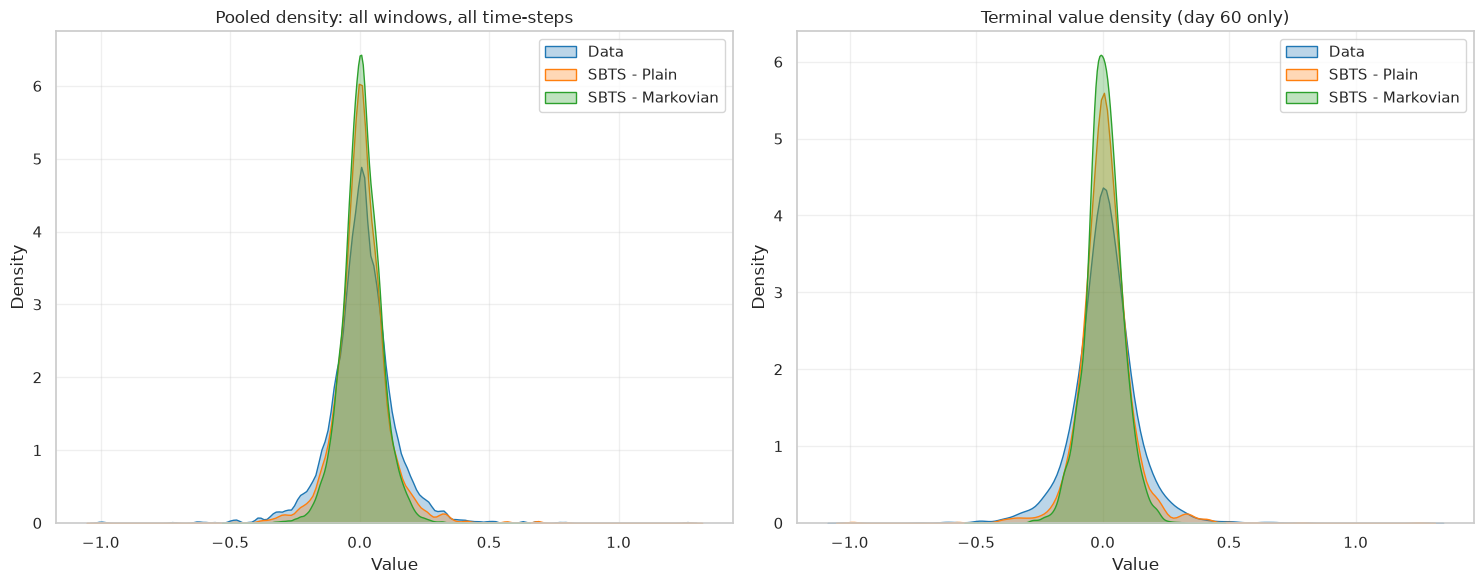

In [9]:
sns.set_theme(style="whitegrid", rc={"grid.alpha": 0.3})

real_flat = R_tilde.flatten()
plain_flat = data_sb_plain.flatten()
mark_flat = data_sb_mark.flatten()

real_t = R_tilde[:, -1]
plain_t = data_sb_plain[:, -1]
mark_t = data_sb_mark[:, -1]

plot_config = {
    "fill": True,
    "common_norm": False,
    "alpha": 0.3,
    "legend": True,
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.kdeplot(real_flat, color="#1f77b4", label="Data", ax=axes[0], **plot_config)
sns.kdeplot(plain_flat, color="#ff7f0e", label="SBTS - Plain", ax=axes[0], **plot_config)
sns.kdeplot(mark_flat, color="#2ca02c", label="SBTS - Markovian", ax=axes[0], **plot_config)
axes[0].set_title("Pooled density: all windows, all time-steps")
axes[0].set_xlabel("Value")

sns.kdeplot(real_t, color="#1f77b4", label="Data", ax=axes[1], **plot_config)
sns.kdeplot(plain_t, color="#ff7f0e", label="SBTS - Plain", ax=axes[1], **plot_config)
sns.kdeplot(mark_t, color="#2ca02c", label="SBTS - Markovian", ax=axes[1], **plot_config)
axes[1].set_title("Terminal value density (day 60 only)")
axes[1].set_xlabel("Value")

for ax in axes:
    ax.legend(title="", fontsize=11, title_fontsize=12)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

Start time: 15:44:58
Expected finish time: 15:45:00
Finish time: 15:45:00
Time with numba to generate 10 samples with N_pi=100: 1 seconds.
Start time: 15:45:00
Expected finish time: 15:45:02
Finish time: 15:45:02
Time with numba to generate 10 samples with N_pi=100: 1 seconds.


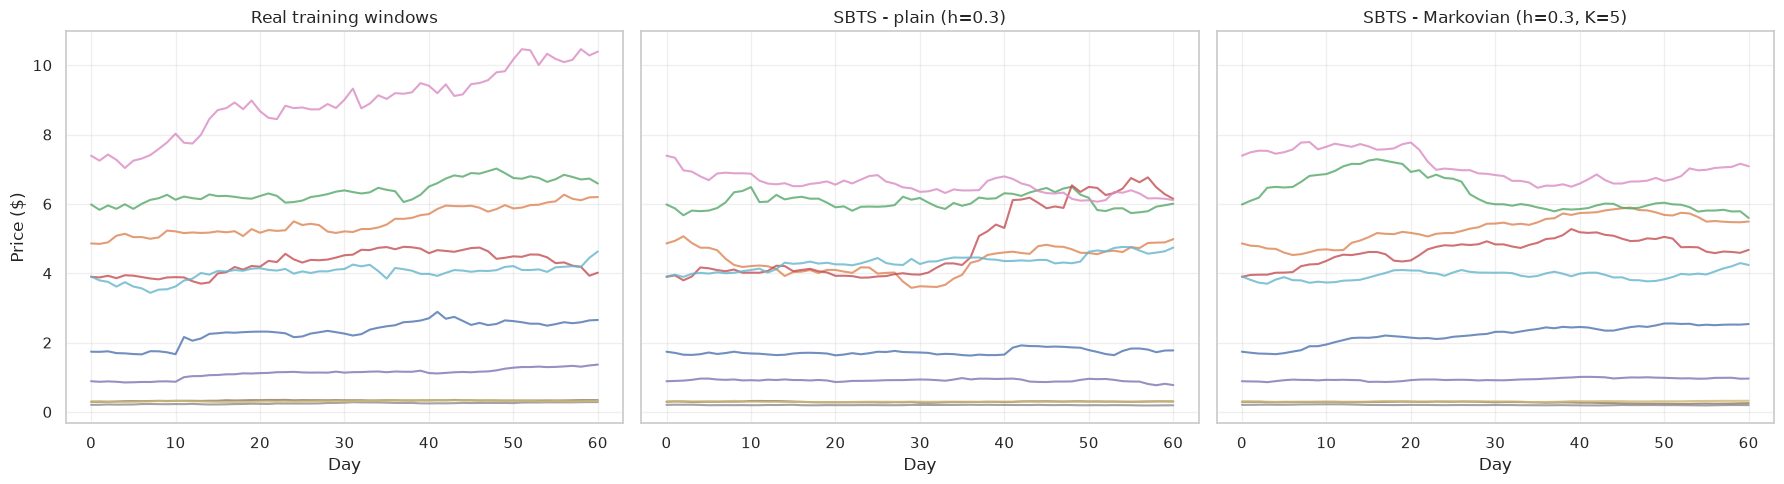

In [10]:
h_plain = h_star
h_mark, K_mark = h_star, best_K
N_pi = 100
deltati = deltat
n_sample = 10

synth_plain = simusbts(N, M, X_ref, N_pi, h_plain, deltati, n_sample)
synth_mark  = simusbts_mark(N, M, K_mark, X_ref, N_pi, h_mark, deltati, n_sample)

def unrescale(synth_rtilde):
    return synth_rtilde * sigma_R / np.sqrt(deltat)

R_synth_plain = unrescale(synth_plain)
R_synth_mark  = unrescale(synth_mark)

rng = np.random.default_rng(7)
start_idx = rng.choice(M, size=n_sample, replace=False)
S0 = X_train[start_idx, 0]

def reconstruct_price(R_synth, S0):
    cum_R = np.cumsum(R_synth, axis=1)
    S = S0[:, None] * np.exp(cum_R)
    return np.concatenate([S0[:, None], S], axis=1)

S_synth_plain = reconstruct_price(R_synth_plain, S0)
S_synth_mark  = reconstruct_price(R_synth_mark, S0)
S_real = X_train[start_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
days = np.arange(N + 1)

for i in range(n_sample):
    axes[0].plot(days, S_real[i], alpha=0.8)
    axes[1].plot(days, S_synth_plain[i], alpha=0.8)
    axes[2].plot(days, S_synth_mark[i], alpha=0.8)

axes[0].set_title("Real training windows")
axes[1].set_title(f"SBTS - plain (h={h_plain})")
axes[2].set_title(f"SBTS - Markovian (h={h_mark}, K={K_mark})")
for ax in axes:
    ax.set_xlabel("Day")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Price ($)")

plt.tight_layout()
plt.savefig("sbts_sample_paths.png", dpi=110)
plt.show()

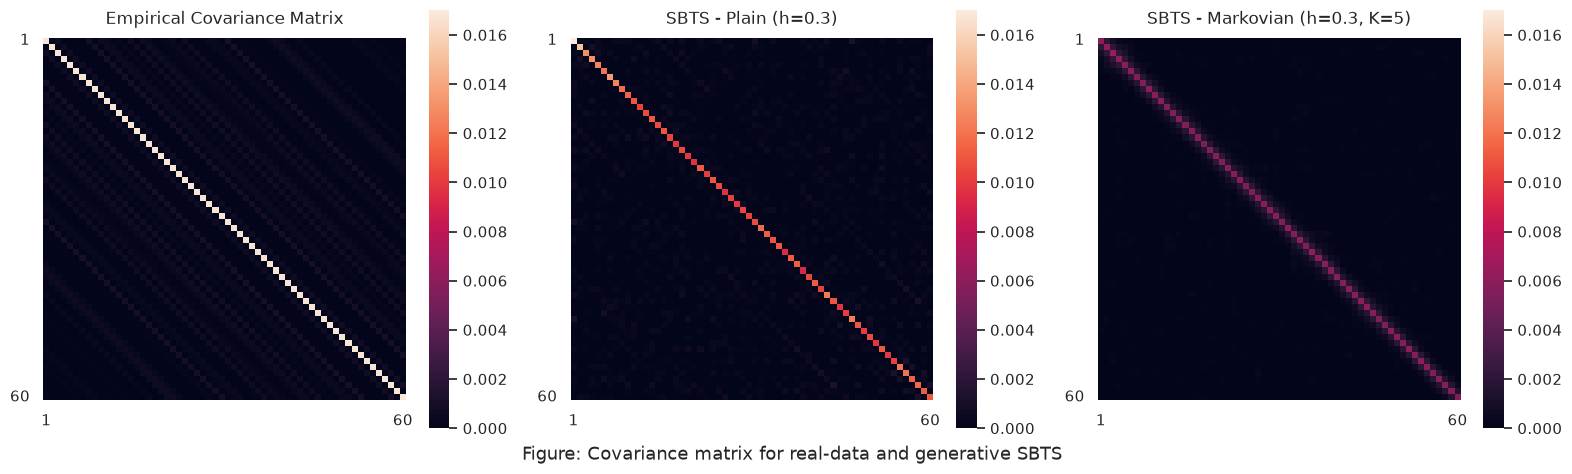

In [11]:
cov_real  = np.cov(R_tilde, rowvar=False)
cov_plain = np.cov(data_sb_plain, rowvar=False)
cov_mark  = np.cov(data_sb_mark, rowvar=False)

vmin = 0.0
vmax = max(cov_real.max(), cov_plain.max(), cov_mark.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

matrices = [cov_real, cov_plain, cov_mark]
titles = [
    "Empirical Covariance Matrix",
    f"SBTS - Plain (h={h_plain})",
    f"SBTS - Markovian (h={h_mark}, K={K_mark})"
]

for ax, matrix, title in zip(axes, matrices, titles):
    sns.heatmap(
        matrix,
        ax=ax,
        cmap="rocket",       
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        square=True
    )
    ax.set_title(title, fontsize=12, pad=10)

    ax.set_xticks([0.5, 59.5])
    ax.set_xticklabels(["1", "60"], rotation=0)
    ax.set_yticks([0.5, 59.5])
    ax.set_yticklabels(["1", "60"], rotation=0)

plt.suptitle("Figure: Covariance matrix for real-data and generative SBTS", y=0.02, fontsize=13)
plt.tight_layout()
plt.savefig("sbts_covariance_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

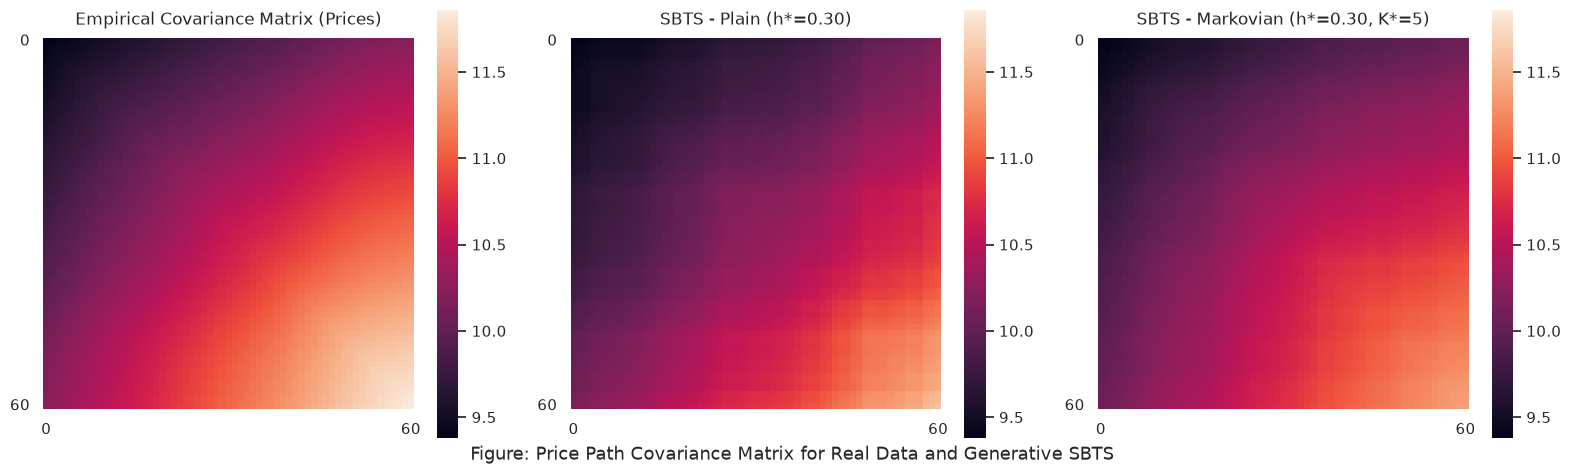

In [12]:
R_synth_plain = data_sb_plain * sigma_R / np.sqrt(deltati)
R_synth_mark  = data_sb_mark  * sigma_R / np.sqrt(deltati)

M_simu = R_synth_plain.shape[0]

rng = np.random.default_rng(7)
start_idx = rng.choice(X_train.shape[0], size=M_simu, replace=False)
S0 = X_train[start_idx, 0]  

def reconstruct_price(R_synth, S0):
    cum_R = np.cumsum(R_synth, axis=1)
    S = S0[:, None] * np.exp(cum_R)
    return np.concatenate([S0[:, None], S], axis=1)

S_real        = X_train[start_idx]                   
S_synth_plain = reconstruct_price(R_synth_plain, S0)  
S_synth_mark  = reconstruct_price(R_synth_mark, S0)   

cov_real  = np.cov(S_real, rowvar=False)
cov_plain = np.cov(S_synth_plain, rowvar=False)
cov_mark  = np.cov(S_synth_mark, rowvar=False)

vmin = min(cov_real.min(), cov_plain.min(), cov_mark.min())
vmax = max(cov_real.max(), cov_plain.max(), cov_mark.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

matrices = [cov_real, cov_plain, cov_mark]
titles = [
    "Empirical Covariance Matrix (Prices)",
    f"SBTS - Plain (h*={h_star:.2f})",
    f"SBTS - Markovian (h*={h_star:.2f}, K*={best_K})"
]

for ax, matrix, title in zip(axes, matrices, titles):
    sns.heatmap(
        matrix,
        ax=ax,
        cmap="rocket",
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        square=True
    )
    ax.set_title(title, fontsize=12, pad=10)
 
    ax.set_xticks([0.5, 60.5])
    ax.set_xticklabels(["0", "60"], rotation=0)
    ax.set_yticks([0.5, 60.5])
    ax.set_yticklabels(["0", "60"], rotation=0)

plt.suptitle("Figure: Price Path Covariance Matrix for Real Data and Generative SBTS", y=0.02, fontsize=13)
plt.tight_layout()
plt.savefig("sbts_price_covariance_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

# Load Data

In [13]:
N = 60

df = yf.download("NVDA", start="2010-01-01", end="2026-01-01", progress=False)
prices = df["Close"].values.flatten()

train_frac, val_frac = 0.70, 0.15
n_total = len(prices)
n_train = int(n_total * train_frac)
n_val   = int(n_total * val_frac)

prices_train = prices[:n_train]
prices_val   = prices[n_train : n_train + n_val]
prices_test  = prices[n_train + n_val :]

def make_windows(prices, N):
    return np.array([prices[i:i+N+1] for i in range(len(prices) - N)])

X = make_windows(prices_train, N)
X_val = make_windows(prices_val, N)
X_test = make_windows(prices_test, N)

numberOfTimeSteps = X.shape[1] - 1

# Raw (un-normalized) version
dic_data_raw = {
    "train": X,
    "val": X_val,
    "test": X_test
}

# Normalized version: each window divided by its own starting price
dic_data = {
    key: prices / prices[:, [0]]
    for key, prices in dic_data_raw.items()
}

In [14]:
dic_data["train"].shape, dic_data["val"].shape, dic_data["test"].shape

((2756, 61), (543, 61), (545, 61))

In [15]:
print("=== Price range check across train/val/test ===\n")
ranges = {}
for key in ["train", "val", "test"]:
    prices = dic_data_raw[key]
    lo, hi = prices.min(), prices.max()
    ranges[key] = (lo, hi)
    print(f"{key:6s}  min={lo:8.2f}   max={hi:8.2f}   mean={prices.mean():8.2f}")

print("\n=== Overlap check ===")
train_lo, train_hi = ranges["train"]
for key in ["val", "test"]:
    lo, hi = ranges[key]
    overlap = not (hi < train_lo or lo > train_hi)
    print(f"{key} overlaps with train's range [{train_lo:.2f}, {train_hi:.2f}]? -> {overlap}")
    if not overlap:
        gap = lo - train_hi if lo > train_hi else train_lo - hi
        print(f"   -> NO OVERLAP. Gap of {gap:.2f} between train's range and {key}'s range.")

=== Price range check across train/val/test ===

train   min=    0.20   max=   15.27   mean=    2.57
val     min=   11.20   max=   47.40   mean=   21.42
test    min=   40.25   max=  206.78   mean=  116.29

=== Overlap check ===
val overlaps with train's range [0.20, 15.27]? -> True
test overlaps with train's range [0.20, 15.27]? -> False
   -> NO OVERLAP. Gap of 24.98 between train's range and test's range.


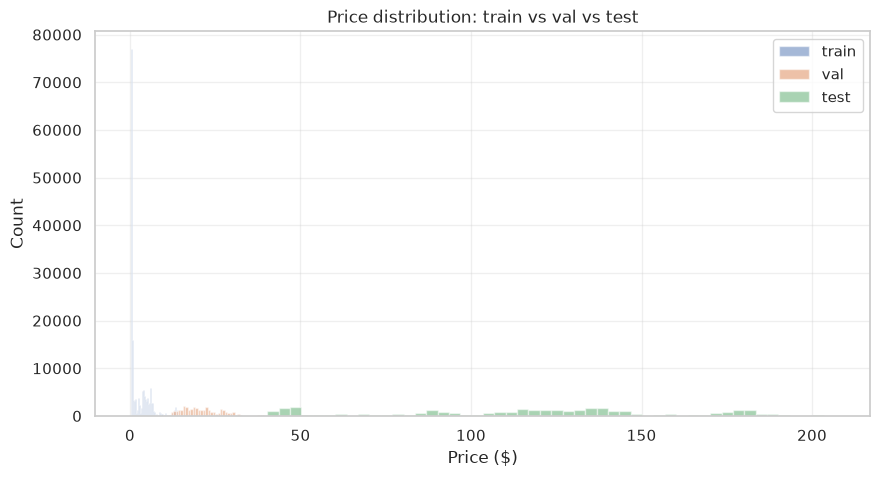

In [16]:
plt.figure(figsize=(10, 5))
for key in ["train", "val", "test"]:
    plt.hist(dic_data_raw[key].flatten(), bins=50, alpha=0.5, label=key)
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.legend()
plt.title("Price distribution: train vs val vs test")
plt.show()

In [17]:
print("=== Price range check across train/val/test ===\n")
ranges = {}
for key in ["train", "val", "test"]:
    prices = dic_data[key]
    lo, hi = prices.min(), prices.max()
    ranges[key] = (lo, hi)
    print(f"{key:6s}  min={lo:8.2f}   max={hi:8.2f}   mean={prices.mean():8.2f}")

print("\n=== Overlap check ===")
train_lo, train_hi = ranges["train"]
for key in ["val", "test"]:
    lo, hi = ranges[key]
    overlap = not (hi < train_lo or lo > train_hi)
    print(f"{key} overlaps with train's range [{train_lo:.2f}, {train_hi:.2f}]? -> {overlap}")
    if not overlap:
        gap = lo - train_hi if lo > train_hi else train_lo - hi
        print(f"   -> NO OVERLAP. Gap of {gap:.2f} between train's range and {key}'s range.")

=== Price range check across train/val/test ===

train   min=    0.44   max=    2.13   mean=    1.05
val     min=    0.54   max=    1.96   mean=    1.08
test    min=    0.64   max=    2.00   mean=    1.10

=== Overlap check ===
val overlaps with train's range [0.44, 2.13]? -> True
test overlaps with train's range [0.44, 2.13]? -> True


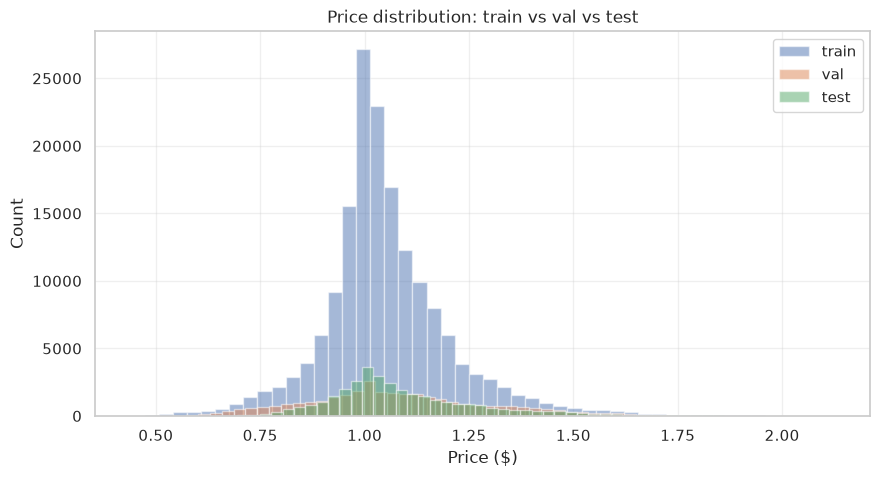

In [18]:
plt.figure(figsize=(10, 5))
for key in ["train", "val", "test"]:
    plt.hist(dic_data[key].flatten(), bins=50, alpha=0.5, label=key)
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.legend()
plt.title("Price distribution: train vs val vs test")
plt.show()

# Deep Hedging using real data

## 1. Train model

In [19]:
deepHedging = DeepHedging(numberOfTimeSteps, dic_data["train"], dic_data["val"], model_name="nvda_data")
deepHedging.train_delta_strategy(1000, 128)


epoch 1/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0446
loss_train = 0.0357499016168308 - loss_val = 0.07698252427170767

epoch 2/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0289
loss_train = 0.021859458182574412 - loss_val = 0.04807130506720635

epoch 3/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0165
loss_train = 0.010925589050075237 - loss_val = 0.023961227266337957

epoch 4/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0077
loss_train = 0.005208482672849225 - loss_val = 0.010149083148308896

epoch 5/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0044
loss_train = 0.003894585978522327 - loss_val = 0.006037518913653449

epoch 6/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0039
loss_train = 0.0038478819314134967 - loss_val = 0.005610374193279645

epoch 7/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0038
loss_train = 0.0038001554344757535 - loss_val = 0.005662938381958389

epoch 8/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s

## 2. Results

In [20]:
print(f"price = {np.round(deepHedging.price.numpy(), 4)}")

price = 0.0705


In [21]:
df_stats_deephedging = pd.DataFrame(columns=["train", "val", "test"], index=["mean", "std"])
for key in df_stats_deephedging.columns:
    time = tf.tile(deepHedging.vtimestep_Euler[tf.newaxis,:], [len(dic_data[key]),1])
    state = tf.concat([time[:,:-1,tf.newaxis], dic_data[key][:,:-1,tf.newaxis]], axis=2)
    strategy_pnl = deepHedging.delta_hedge(state)[:,:,0] * tf.experimental.numpy.diff(dic_data[key], n=1, axis=-1)

    Pnl = deepHedging.price.numpy() + tf.reduce_sum(strategy_pnl, axis=1).numpy()

    K = dic_data[key][:, 0]
    payoff = deepHedging.payoff(dic_data[key][:,-1], K).numpy()

    df_stats_deephedging.loc["mean", key] = np.mean(Pnl - payoff)  
    df_stats_deephedging.loc["std", key]  = np.std(Pnl - payoff)    

df_stats_deephedging

,train,val,test
mean,-0.0034,-0.030469,-0.017151
std,0.032903,0.025203,0.028832


# Deep Hedging using SBTS data

## 1. Train model

In [22]:
# data_sb_plain: raw SBTS output rescaled log-returns
print(data_sb_plain.shape) 

# Un-rescale back to real log-return scale
R_synth_plain = data_sb_plain * sigma_R / np.sqrt(deltat)

# Reconstruct actual price paths
rng = np.random.default_rng(123)
S0 = dic_data["train"][rng.integers(0, dic_data["train"].shape[0], size=data_sb_plain.shape[0]), 0]

cum_R = np.cumsum(R_synth_plain, axis=1)
S = S0[:, None] * np.exp(cum_R)
X_sb_plain = np.concatenate([S0[:, None], S], axis=1)   

print(X_sb_plain.shape)  

(2756, 60)
(2756, 61)


In [23]:
deepHedgingSimu = DeepHedging(numberOfTimeSteps, X_sb_plain, dic_data["val"], model_name="nvda_sbts_plain")
deepHedgingSimu.train_delta_strategy(1000, 128)


epoch 1/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0430
loss_train = 0.034562162491338 - loss_val = 0.10124673508012448

epoch 2/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0283
loss_train = 0.022889319126583357 - loss_val = 0.06876836383416511

epoch 3/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0182
loss_train = 0.014591867044473504 - loss_val = 0.04435941269182418

epoch 4/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0114
loss_train = 0.008391583931825658 - loss_val = 0.02501179632281982

epoch 5/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0064
loss_train = 0.004659405624495164 - loss_val = 0.01276599275929215

epoch 6/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0038
loss_train = 0.0031118685907031356 - loss_val = 0.007596843214093905

epoch 7/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0029
loss_train = 0.0026925298087859648 - loss_val = 0.00653590819016964

epoch 8/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms

In [24]:
print(f"price = {np.round(deepHedgingSimu.price.numpy(), 8)}")

price = 0.05976658


In [25]:
df_stats_deephedgingSimu = pd.DataFrame(columns=["train", "val", "test"], index=["mean", "std"])
for key in df_stats_deephedgingSimu.columns:
    time = tf.tile(deepHedgingSimu.vtimestep_Euler[tf.newaxis,:], [len(dic_data[key]),1])
    state = tf.concat([time[:,:-1,tf.newaxis], dic_data[key][:,:-1,tf.newaxis]], axis=2)
    strategy_pnl = deepHedgingSimu.delta_hedge(state)[:,:,0] * tf.experimental.numpy.diff(dic_data[key], n=1, axis=-1)

    Pnl = deepHedgingSimu.price.numpy() + tf.reduce_sum(strategy_pnl, axis=1).numpy()

    K = dic_data[key][:, 0]
    payoff = deepHedgingSimu.payoff(dic_data[key][:,-1], K).numpy()

    df_stats_deephedgingSimu.loc["mean", key] = np.mean(Pnl - payoff)
    df_stats_deephedgingSimu.loc["std", key]  = np.std(Pnl - payoff)

df_stats_deephedgingSimu

,train,val,test
mean,-0.011214,-0.03012,-0.023891
std,0.034911,0.033544,0.035761


# Markov SBTS

In [26]:
# data_sb_mark: raw SBTS output rescaled log-returns
print(data_sb_mark.shape) 

# Un-rescale back to real log-return scale
R_synth_mark = data_sb_mark * sigma_R / np.sqrt(deltat)

# Reconstruct actual price paths
rng = np.random.default_rng(123)
S0 = dic_data["train"][rng.integers(0, dic_data["train"].shape[0], size=data_sb_mark.shape[0]), 0]

cum_R = np.cumsum(R_synth_mark, axis=1)
S = S0[:, None] * np.exp(cum_R)
X_sb_mark = np.concatenate([S0[:, None], S], axis=1)  

print(X_sb_mark.shape)  

(2756, 60)
(2756, 61)


In [27]:
deepHedgingSimuMark = DeepHedging(numberOfTimeSteps, X_sb_mark, dic_data["val"], model_name="nvda_sbts_mark")
deepHedgingSimuMark.train_delta_strategy(1000, 128)


epoch 1/1000


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0301
loss_train = 0.022267911970949773 - loss_val = 0.0724775299474481

epoch 2/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0170
loss_train = 0.011730265675641257 - loss_val = 0.04103828714220914

epoch 3/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0082
loss_train = 0.005055096493445227 - loss_val = 0.019190242547934406

epoch 4/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0035
loss_train = 0.0023346590343067096 - loss_val = 0.008784937085873508

epoch 5/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0020
loss_train = 0.001937518910269132 - loss_val = 0.006454479061520182

epoch 6/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0019
loss_train = 0.001913520528515693 - loss_val = 0.006320671396856403

epoch 7/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0019
loss_train = 0.0018733059639178741 - loss_val = 0.006505367442778179

epoch 8/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - 

In [28]:
print(f"price = {np.round(deepHedgingSimuMark.price.numpy(), 8)}")

price = 0.04668469


In [29]:
df_stats_deephedgingSimuMark = pd.DataFrame(columns=["train", "val", "test"], index=["mean", "std"])
for key in df_stats_deephedgingSimuMark.columns:
    time = tf.tile(deepHedgingSimuMark.vtimestep_Euler[tf.newaxis,:], [len(dic_data[key]),1])
    state = tf.concat([time[:,:-1,tf.newaxis], dic_data[key][:,:-1,tf.newaxis]], axis=2)
    strategy_pnl = deepHedgingSimuMark.delta_hedge(state)[:,:,0] * tf.experimental.numpy.diff(dic_data[key], n=1, axis=-1)

    Pnl = deepHedgingSimuMark.price.numpy() + tf.reduce_sum(strategy_pnl, axis=1).numpy()

    K = dic_data[key][:, 0]
    payoff = deepHedgingSimuMark.payoff(dic_data[key][:,-1], K).numpy()

    df_stats_deephedgingSimuMark.loc["mean", key] = np.mean(Pnl - payoff)
    df_stats_deephedgingSimuMark.loc["std", key]  = np.std(Pnl - payoff)

df_stats_deephedgingSimuMark

,train,val,test
mean,-0.028906,-0.046535,-0.048054
std,0.041541,0.036918,0.044313


# PnL distribution Data versus SBTS

In [30]:
dic_deephedging_pnl = {}

def get_pnl(deepHedging_model, key):
    time = tf.tile(deepHedging_model.vtimestep_Euler[tf.newaxis,:], [len(dic_data[key]),1])
    state = tf.concat([time[:,:-1,tf.newaxis], dic_data[key][:,:-1,tf.newaxis]], axis=2)
    strategy_pnl = deepHedging_model.delta_hedge(state)[:,:,0] * tf.experimental.numpy.diff(dic_data[key], n=1, axis=-1)

    Pnl = deepHedging_model.price.numpy() + tf.reduce_sum(strategy_pnl, axis=1).numpy()

    K = dic_data[key][:, 0]
    payoff = deepHedging_model.payoff(dic_data[key][:,-1], K).numpy()

    return Pnl - payoff

dic_deephedging_pnl_val = {
    "Data": get_pnl(deepHedging, "val"),
    "SBTS": get_pnl(deepHedgingSimu, "val"),
    "SBTS_Markov": get_pnl(deepHedgingSimuMark, "val")
}

dic_deephedging_pnl_test = {
    "Data": get_pnl(deepHedging, "test"),
    "SBTS": get_pnl(deepHedgingSimu, "test"),
    "SBTS_Markov": get_pnl(deepHedgingSimuMark, "test")
}

In [31]:
def plot_pnl_distribution(dic_deephedging_pnl):
    sns.set_style("whitegrid")

    df_plot = pd.DataFrame()
    pnl_all, legend_all = [], []
    for key, pnl in dic_deephedging_pnl.items():
        pnl_all.extend(np.asarray(pnl).tolist())
        legend_all.extend([key] * len(pnl))

    df_plot["PnL"] = pnl_all
    df_plot["Legend"] = legend_all

    ax = sns.displot(data=df_plot, x="PnL", hue="Legend", kind="kde", height=7, fill=True, ec='Navy', lw=2, alpha=0.5)
    plt.xlabel(r"$\mathrm{PnL}$", fontsize=14)
    plt.ylabel(r"$\mathrm{Density}$", fontsize=14)
    ax._legend.get_title().set_text("")
    plt.setp(ax._legend.get_texts(), fontsize=14)
    return ax

## 1. Validation

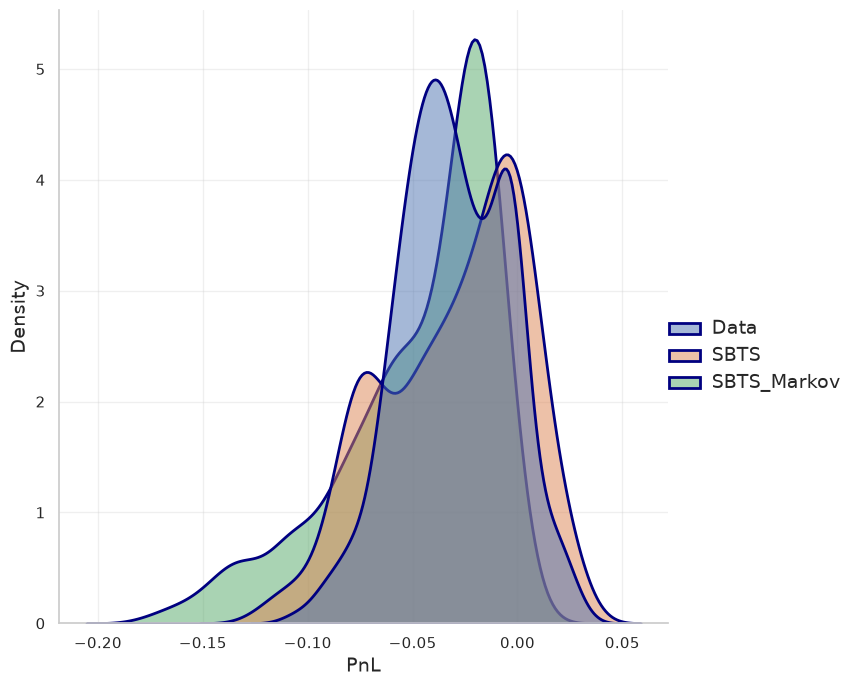

In [32]:
plot_pnl_distribution(dic_deephedging_pnl_val)

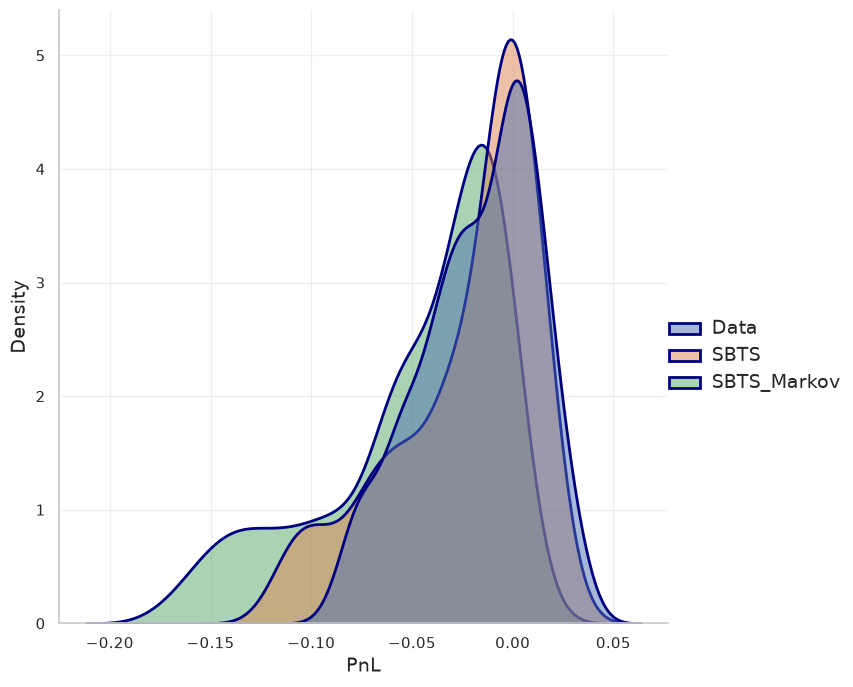

In [33]:
plot_pnl_distribution(dic_deephedging_pnl_test)

In [34]:
def plot_pnl_pair(dic_deephedging_pnl, key_a="Data", key_b="SBTS", title=None):
    sns.set_style("whitegrid")

    df_plot = pd.DataFrame()
    pnl_all, legend_all = [], []
    for key in [key_a, key_b]:
        pnl = np.asarray(dic_deephedging_pnl[key])
        pnl_all.extend(pnl.tolist())
        legend_all.extend([key] * len(pnl))

        print(f"{key:15s}  mean = {pnl.mean(): .5f}   std = {pnl.std():.5f}")

    df_plot["PnL"] = pnl_all
    df_plot["Legend"] = legend_all

    ax = sns.displot(data=df_plot, x="PnL", hue="Legend", kind="kde", height=7, fill=True, ec='Navy', lw=2, alpha=0.5)
    plt.xlabel(r"$\mathrm{PnL}$", fontsize=14)
    plt.ylabel(r"$\mathrm{Density}$", fontsize=14)
    ax._legend.get_title().set_text("")
    plt.setp(ax._legend.get_texts(), fontsize=14)
    if title:
        plt.title(title, fontsize=14)
    return ax

=== Data vs SBTS (plain) ===
Data             mean = -0.03047   std = 0.02520
SBTS             mean = -0.03012   std = 0.03354


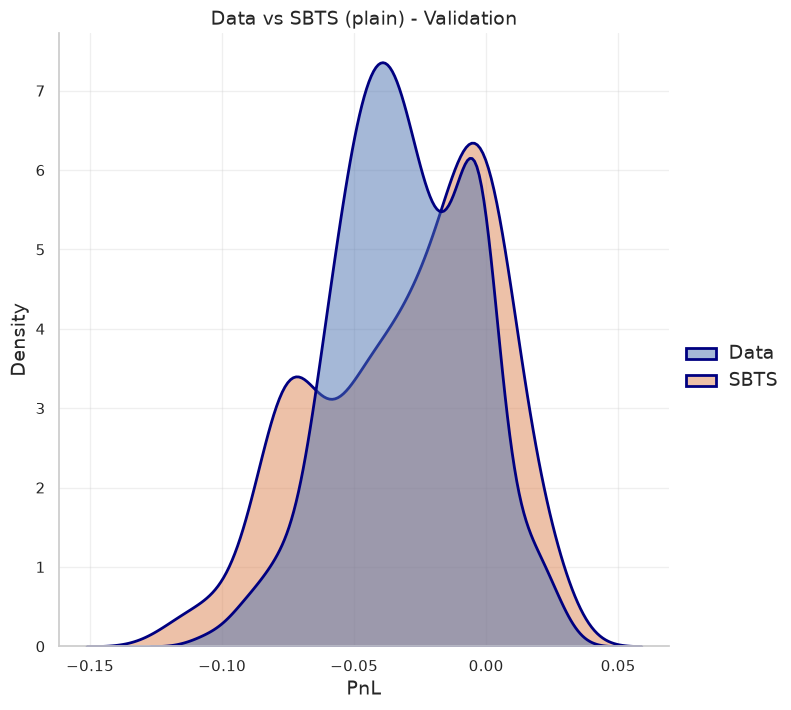


=== Data vs SBTS (Markovian) ===
Data             mean = -0.03047   std = 0.02520
SBTS_Markov      mean = -0.04654   std = 0.03692


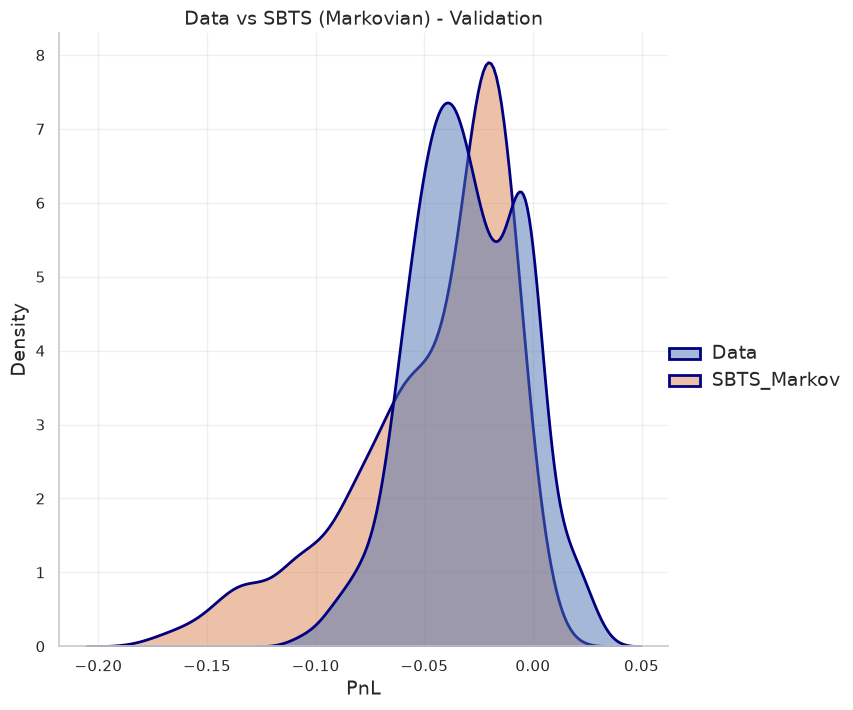

In [35]:
print("=== Data vs SBTS (plain) ===")
plot_pnl_pair(dic_deephedging_pnl_val, "Data", "SBTS", title="Data vs SBTS (plain) - Validation")
plt.show()

print("\n=== Data vs SBTS (Markovian) ===")
plot_pnl_pair(dic_deephedging_pnl_val, "Data", "SBTS_Markov", title="Data vs SBTS (Markovian) - Validation")
plt.show()

Data             mean = -0.01715   std = 0.02883
SBTS             mean = -0.02389   std = 0.03576


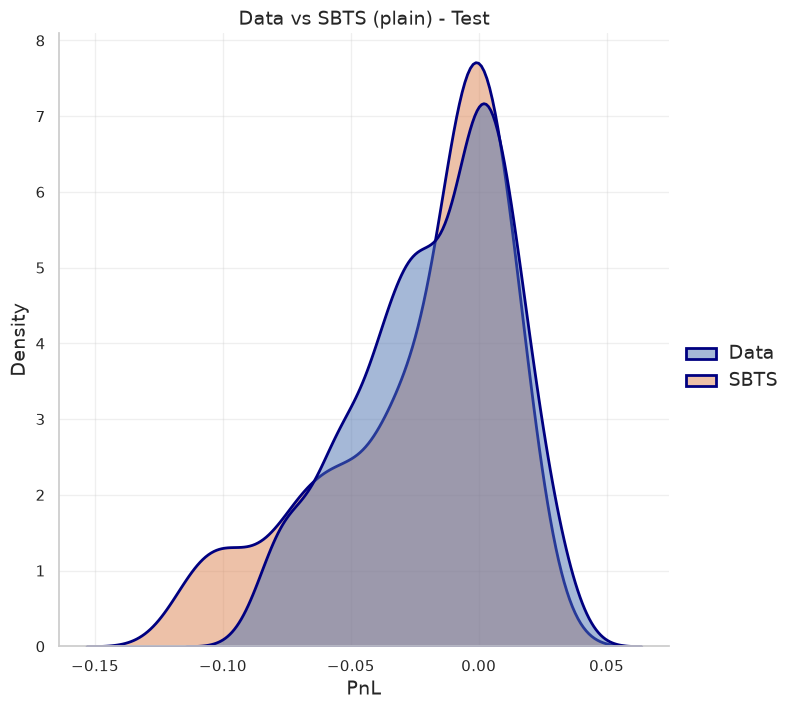

Data             mean = -0.01715   std = 0.02883
SBTS_Markov      mean = -0.04805   std = 0.04431


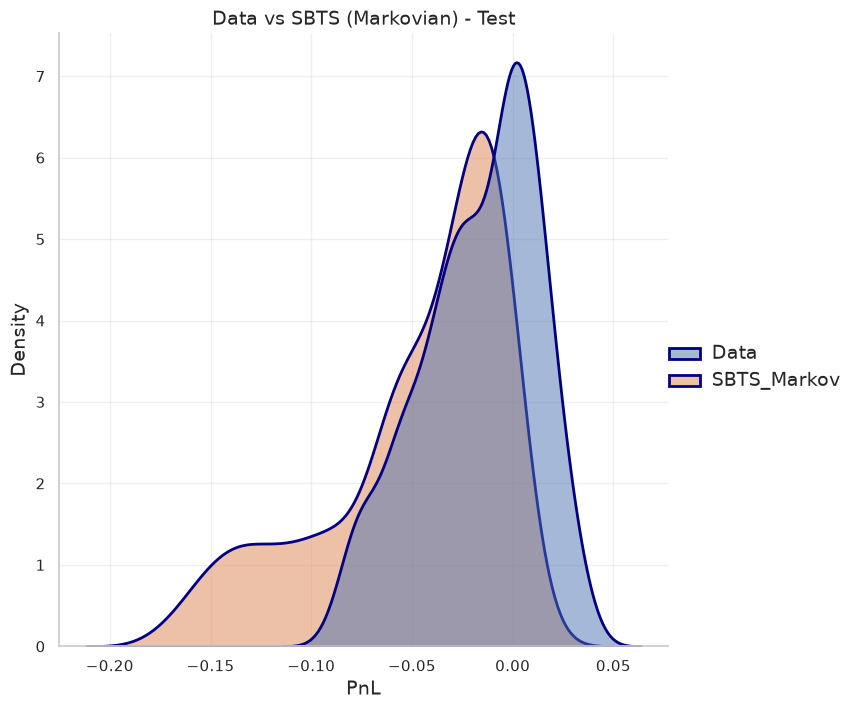

In [36]:
# Data vs SBTS (plain)
plot_pnl_pair(dic_deephedging_pnl_test, "Data", "SBTS", title="Data vs SBTS (plain) - Test")
plt.show()

# Data vs SBTS_Markov
plot_pnl_pair(dic_deephedging_pnl_test, "Data", "SBTS_Markov", title="Data vs SBTS (Markovian) - Test")
plt.show()